This runs all segmentation operations in one place.
The idea is that this should be faster and easier to envoke as we only have to load the image data once instead of N times (~10).
Running each individual task as its own script is modular but requires overhead to load the data each time.


In [1]:
import argparse
import json
import os
import pathlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import scipy
import tifffile
import torch
from cellpose import models
from image_analysis_3D.featurization_utils.resource_profiling_util import (
    start_profiling,
    stop_profiling,
)
from image_analysis_3D.file_utils.arg_parsing_utils import (
    check_for_missing_args,
    parse_args,
)
from image_analysis_3D.file_utils.file_reading import (
    find_files_available,
    read_in_channels,
    read_zstack_image,
)
from image_analysis_3D.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)
from image_analysis_3D.file_utils.read_in_channel_mapping import *
from image_analysis_3D.file_utils.read_in_channel_mapping import (
    retrieve_channel_mapping,
)
from image_analysis_3D.segmentation_utils.cell_segmentation import *
from image_analysis_3D.segmentation_utils.general_segmentation_utils import *
from image_analysis_3D.segmentation_utils.nuclei_segmentation import *
from image_analysis_3D.segmentation_utils.segmentation_decoupling import *
from skimage.filters import sobel
from skimage.segmentation import relabel_sequential

In [2]:
start_time, start_mem = start_profiling()

In [3]:
root_dir, in_notebook = init_notebook()

image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve(), root_dir
)

In [4]:
if not in_notebook:
    args = parse_args()
    clip_limit = args["clip_limit"]
    well_fov = args["well_fov"]
    patient = args["patient"]
    input_subparent_name = args["input_subparent_name"]
    mask_subparent_name = args["mask_subparent_name"]
    check_for_missing_args(
        well_fov=well_fov,
        patient=patient,
        clip_limit=clip_limit,
        input_subparent_name=input_subparent_name,
        mask_subparent_name=mask_subparent_name,
    )
else:
    print("Running in a notebook")
    patient = "NF0021_T1"
    well_fov = "G7-2"
    clip_limit = 0.03
    input_subparent_name = "zstack_images"
    mask_subparent_name = "segmentation_masks"


window_size = 2
input_dir = pathlib.Path(
    f"{image_base_dir}/data/{patient}/{input_subparent_name}/{well_fov}"
).resolve(strict=True)
mask_path = pathlib.Path(
    f"{image_base_dir}/data/{patient}/{mask_subparent_name}/{well_fov}"
).resolve()
mask_path.mkdir(exist_ok=True, parents=True)
channel_dict = retrieve_channel_mapping(f"{root_dir}/config/channel_mapping.toml")

Running in a notebook


In [5]:
return_dict = read_in_channels(
    find_files_available(input_dir),
    channel_dict=channel_dict,
    channels_to_read=["AGP"],
)
cyto2_raw = return_dict["AGP"]
del return_dict
# run clip_limit here
cyto2 = skimage.exposure.equalize_adapthist(
    cyto2_raw, clip_limit=clip_limit, kernel_size=None
)
del cyto2_raw

In [6]:
# apply gaussian blur to smooth out the image after thresholding
threshold_cyto2 = skimage.filters.threshold_otsu(cyto2)
thresholded_cyto2 = cyto2 > threshold_cyto2
thresholded_cyto2 = skimage.filters.gaussian(thresholded_cyto2, sigma=10)

## Segment the organoids

In [7]:
organoid_image_shape = cyto2.shape
organoid_mask = np.array(  # convert to array
    list(  # send to list
        decouple_masks(  # 4. decouple masks
            reverse_sliding_window_max_projection(  # 3. reverse sliding window
                segmentaion_on_two_D(  # 2. segment on 2D
                    sliding_window_two_point_five_D(  # 1. run sliding window
                        image_stack=thresholded_cyto2, window_size=3
                    ),
                    diameter=200,
                ),
                window_size=3,
                original_z_slice_count=organoid_image_shape[0],
            ),
            original_img_shape=organoid_image_shape,
            distance_threshold=10,
        ).values()
    )
)

100%|██████████| 35/35 [00:04<00:00,  8.14it/s]


In [8]:
organoid_mask, diag = object_stitching_and_relation(
    input_masks=organoid_mask,
    max_match_distance=100,
    verbose=False,
)

## Remove border objects

In [9]:
# nuclei should already have objects removed at the border from the previous notebook,
# but we can run this again just to be safe
organoid_mask = clean_border_objects(organoid_mask, border_width=5)

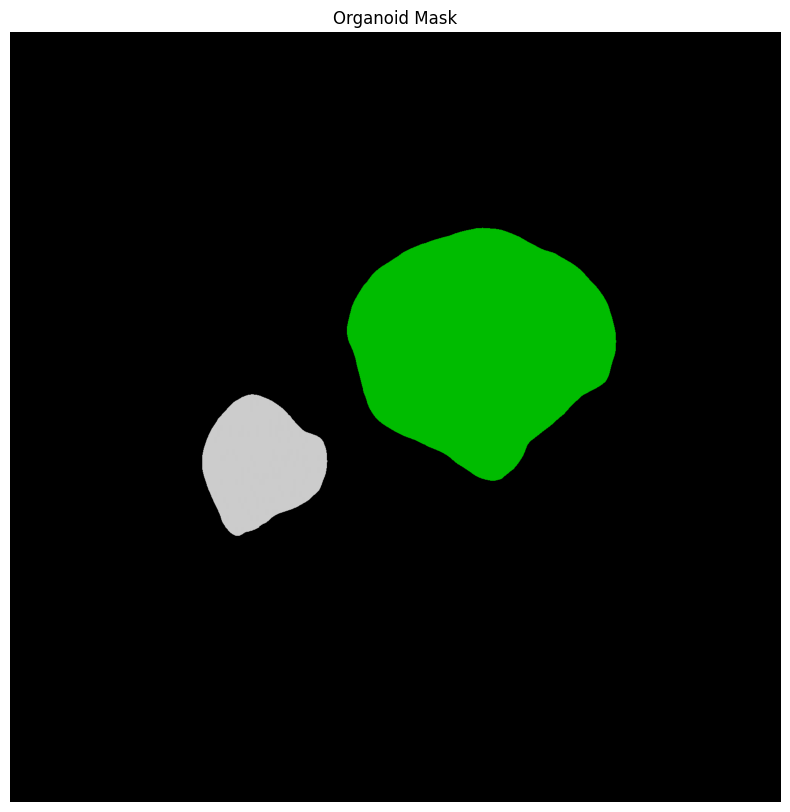

In [10]:
if in_notebook:
    z = organoid_mask.shape[0] // 2
    plt.figure(figsize=(10, 10))
    plt.title("Organoid Mask")
    plt.imshow(organoid_mask[z, :, :], cmap="nipy_spectral")
    plt.axis("off")
    plt.show()

## Save the segmented masks

In [11]:
organoid_mask_output = pathlib.Path(f"{mask_path}/organoid_mask.tiff")

tifffile.imwrite(organoid_mask_output, organoid_mask)

In [12]:
stop_profiling(
    start_time=start_time,
    start_mem=start_mem,
    feature_type="Segmentation",
    well_fov=well_fov,
    patient_id=patient,
    channel="NoChannel",
    compartment="organoid",
    CPU_GPU="GPU",
    output_file_dir=pathlib.Path(
        f"{image_base_dir}/data/{patient}/segmentation_masks/run_stats/{well_fov}_organoid_segmentation.parquet"
    ),
)


        Memory and time profiling for the run:
        Patient ID: NF0021_T1
        Well and FOV: G7-2
        Feature type: Segmentation
        CPU/GPU: GPU
        Peak memory (tracemalloc): 4473.02 MB
        Current memory (tracemalloc): 1349.26 MB
        RSS at end: 4471.20 MB
        Time elapsed:
        --- 75.74 seconds ---
        --- 1.26 minutes ---
        --- 0.02 hours ---
    


True

Note for an image of the pixel size (20, 1500, 1500) (Z,Y,X). 
This runs in under 1 minute on a CPU and uses less than 1GB of RAM.